In [1]:
!pip install fastf1

In [2]:
import fastf1
import pandas as pd
import numpy as np
print(fastf1.__version__)

3.6.0


In [3]:
session = fastf1.get_session(2021, 'French Grand Prix', 'Q')
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (111.97 MB) C:\Users\91767\AppData\Local\Temp\fastf1
core           INFO 	Loading data for French Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['33', '44', '77', '11', '55', '10', '16', '4', '14', '3', '31', '5', '99', '63', '47', '6', '7', '9', '18', '22']


In [4]:
session.event

RoundNumber                                                     7
Country                                                    France
Location                                             Le Castellet
OfficialEventName    FORMULA 1 EMIRATES GRAND PRIX DE FRANCE 2021
EventDate                                     2021-06-20 00:00:00
EventName                                       French Grand Prix
EventFormat                                          conventional
Session1                                               Practice 1
Session1Date                            2021-06-18 11:30:00+02:00
Session1DateUtc                               2021-06-18 09:30:00
Session2                                               Practice 2
Session2Date                            2021-06-18 15:00:00+02:00
Session2DateUtc                               2021-06-18 13:00:00
Session3                                               Practice 3
Session3Date                            2021-06-19 12:00:00+02:00
Session3Da

In [4]:
get_data_f1 = session.laps
get_data_f1

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:17:35.479000,GAS,10,NaT,1.0,1.0,0 days 00:14:47.810000,NaT,0 days 00:00:48.895000,0 days 00:00:46.957000,...,True,AlphaTauri,0 days 00:14:47.810000,2021-06-19 13:00:15.013,1,NaN,False,,False,False
1,0 days 00:27:42.702000,GAS,10,NaT,2.0,1.0,NaT,0 days 00:19:40.614000,0 days 00:00:23.040000,NaT,...,True,AlphaTauri,0 days 00:17:35.479000,2021-06-19 13:03:02.682,125,NaN,False,,False,False
2,0 days 00:30:15.038000,GAS,10,NaT,3.0,2.0,0 days 00:27:42.702000,NaT,0 days 00:00:43.813000,0 days 00:00:40.047000,...,False,AlphaTauri,0 days 00:27:42.702000,2021-06-19 13:13:09.905,1,NaN,False,,False,False
3,0 days 00:31:46.936000,GAS,10,0 days 00:01:31.898000,4.0,2.0,NaT,NaT,0 days 00:00:22.843000,0 days 00:00:27.881000,...,False,AlphaTauri,0 days 00:30:15.038000,2021-06-19 13:15:42.241,1,NaN,False,,False,True
4,0 days 00:34:20.695000,GAS,10,NaT,5.0,2.0,NaT,NaT,0 days 00:00:37.442000,0 days 00:00:47.382000,...,False,AlphaTauri,0 days 00:31:46.936000,2021-06-19 13:17:14.139,1,NaN,False,,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0 days 00:54:22.881000,GIO,99,0 days 00:01:32.182000,9.0,4.0,NaT,NaT,0 days 00:00:23.146000,0 days 00:00:27.947000,...,True,Alfa Romeo Racing,0 days 00:52:50.699000,2021-06-19 13:38:17.902,1,NaN,False,,False,True
266,0 days 01:00:32.369000,GIO,99,NaT,10.0,4.0,NaT,0 days 00:56:04.344000,0 days 00:00:26.297000,0 days 00:00:33.082000,...,True,Alfa Romeo Racing,0 days 00:54:22.881000,2021-06-19 13:39:50.084,1,NaN,False,,False,False
267,0 days 01:03:24.940000,GIO,99,NaT,11.0,5.0,0 days 01:00:32.260000,NaT,0 days 00:00:49.673000,0 days 00:00:41.499000,...,True,Alfa Romeo Racing,0 days 01:00:32.369000,2021-06-19 13:45:59.572,1,NaN,False,,False,False
268,0 days 01:04:56.753000,GIO,99,0 days 00:01:31.813000,12.0,5.0,NaT,NaT,0 days 00:00:22.846000,0 days 00:00:27.868000,...,True,Alfa Romeo Racing,0 days 01:03:24.940000,2021-06-19 13:48:52.143,1,NaN,False,,False,True


In [8]:
import re
import pandas as pd
import numpy as np
import psycopg2
from psycopg2 import sql

# --- 1. Sanitize table name ---
table_name = 'session'
clean_table_name = re.sub(r'\W+', '_', table_name)

# --- 2. Infer SQL types from pandas dtypes ---
def infer_sql_types(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'TIMESTAMP'
    else:
        return 'TEXT'

# --- 3. Build CREATE TABLE statement ---
columns = get_data_f1.dtypes
sql_columns = ',\n '.join([f'"{col}" {infer_sql_types(dtype)}' for col, dtype in columns.items()])

create_stmt = f"""
CREATE TABLE IF NOT EXISTS {clean_table_name} (
 {sql_columns}
);
"""

# --- 4. Connect and insert data ---
conn = None
try:
    conn = psycopg2.connect(
        dbname="postgres",
        user="postgres",
        password="postgres",
        host="localhost",
        port="5432"
    )
    cur = conn.cursor()

    # Create table
    cur.execute(create_stmt)
    conn.commit()

    # Prepare INSERT statement safely
    columns_list = list(get_data_f1.columns)
    placeholders = ', '.join(['%s'] * len(columns_list))
    insert_stmt = sql.SQL("INSERT INTO {} ({}) VALUES ({})").format(
        sql.Identifier(clean_table_name),
        sql.SQL(', ').join(map(sql.Identifier, columns_list)),
        sql.SQL(placeholders)
    )

    # Replace NaN with None to avoid insert errors
    data = [tuple(None if pd.isna(x) else x for x in row) for row in get_data_f1.to_numpy()]

    # Bulk insert
    cur.executemany(insert_stmt.as_string(conn), data)
    conn.commit()

    print(f"✅ Data inserted successfully into table: {clean_table_name}")

except Exception as e:
    print(f"❌ Error: {e}")
    if conn:
        conn.rollback()
finally:
    if conn:
        cur.close()
        conn.close()

✅ Data inserted successfully into table: session


In [6]:
get_data_result = session.results
get_data_result.isnull().sum()

DriverNumber           0
BroadcastName          0
Abbreviation           0
DriverId               0
TeamName               0
TeamColor              0
TeamId                 0
FirstName              0
LastName               0
FullName               0
HeadshotUrl            0
CountryCode            0
Position               0
ClassifiedPosition     0
GridPosition          20
Q1                     2
Q2                     6
Q3                    10
Time                  20
Status                 0
Points                20
Laps                  20
dtype: int64

In [7]:
null_counts = get_data_result.isnull().sum()
cols_to_drop = null_counts[null_counts > 10].index
df = get_data_result.drop(cols_to_drop, axis=1)
df.isnull().sum()
df['Q3'].mean()
df['Q3'].fillna('0 days 00:01:30.772800',inplace = True)
df['Q2'].mean()
df['Q2'].fillna('00:01:31.409071428',inplace = True)
df['Q1'].mean()
df['Q1'].fillna('00:01:32.260555555',inplace = True)
df.isnull().sum()

DriverNumber          0
BroadcastName         0
Abbreviation          0
DriverId              0
TeamName              0
TeamColor             0
TeamId                0
FirstName             0
LastName              0
FullName              0
HeadshotUrl           0
CountryCode           0
Position              0
ClassifiedPosition    0
Q1                    0
Q2                    0
Q3                    0
Status                0
dtype: int64

In [8]:
df

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,HeadshotUrl,CountryCode,Position,ClassifiedPosition,Q1,Q2,Q3,Status
33,33,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,0600EF,red_bull,Max,Verstappen,Max Verstappen,https://www.formula1.com/content/dam/fom-websi...,,1.0,,0 days 00:01:31.001000,0 days 00:01:31.080000,0 days 00:01:29.990000,
44,44,L HAMILTON,HAM,hamilton,Mercedes,00D2BE,mercedes,Lewis,Hamilton,Lewis Hamilton,https://www.formula1.com/content/dam/fom-websi...,,2.0,,0 days 00:01:31.237000,0 days 00:01:30.788000,0 days 00:01:30.248000,
77,77,V BOTTAS,BOT,bottas,Mercedes,00D2BE,mercedes,Valtteri,Bottas,Valtteri Bottas,https://www.formula1.com/content/dam/fom-websi...,,3.0,,0 days 00:01:31.669000,0 days 00:01:30.735000,0 days 00:01:30.376000,
11,11,S PEREZ,PER,perez,Red Bull Racing,0600EF,red_bull,Sergio,Perez,Sergio Perez,https://www.formula1.com/content/dam/fom-websi...,,4.0,,0 days 00:01:31.560000,0 days 00:01:30.971000,0 days 00:01:30.445000,
55,55,C SAINZ,SAI,sainz,Ferrari,DC0004,ferrari,Carlos,Sainz,Carlos Sainz,https://www.formula1.com/content/dam/fom-websi...,,5.0,,0 days 00:01:32.079000,0 days 00:01:31.146000,0 days 00:01:30.840000,
10,10,P GASLY,GAS,gasly,AlphaTauri,2B4562,alphatauri,Pierre,Gasly,Pierre Gasly,https://www.formula1.com/content/dam/fom-websi...,,6.0,,0 days 00:01:31.898000,0 days 00:01:31.353000,0 days 00:01:30.868000,
16,16,C LECLERC,LEC,leclerc,Ferrari,DC0004,ferrari,Charles,Leclerc,Charles Leclerc,https://www.formula1.com/content/dam/fom-websi...,,7.0,,0 days 00:01:32.209000,0 days 00:01:31.567000,0 days 00:01:30.987000,
4,4,L NORRIS,NOR,norris,McLaren,FF9800,mclaren,Lando,Norris,Lando Norris,https://www.formula1.com/content/dam/fom-websi...,,8.0,,0 days 00:01:31.733000,0 days 00:01:31.542000,0 days 00:01:31.252000,
14,14,F ALONSO,ALO,alonso,Alpine,0090FF,alpine,Fernando,Alonso,Fernando Alonso,https://www.formula1.com/content/dam/fom-websi...,,9.0,,0 days 00:01:32.158000,0 days 00:01:31.549000,0 days 00:01:31.340000,
3,3,D RICCIARDO,RIC,ricciardo,McLaren,FF9800,mclaren,Daniel,Ricciardo,Daniel Ricciardo,https://www.formula1.com/content/dam/fom-websi...,,10.0,,0 days 00:01:32.181000,0 days 00:01:31.615000,0 days 00:01:31.382000,


In [9]:
def infer_sql_types(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'TIMESTAMP'
    else:
        return 'TEXT'
table_name = 'session_results'
columns = df.dtypes
sql_columns = ',\n '.join([f'"{col}"{infer_sql_types(dtype)}' for col, dtype in columns.items()])

create_stmt = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
 {sql_columns}
);
"""

print(create_stmt)


CREATE TABLE IF NOT EXISTS session_results (
 "DriverNumber"TEXT,
 "BroadcastName"TEXT,
 "Abbreviation"TEXT,
 "DriverId"TEXT,
 "TeamName"TEXT,
 "TeamColor"TEXT,
 "TeamId"TEXT,
 "FirstName"TEXT,
 "LastName"TEXT,
 "FullName"TEXT,
 "HeadshotUrl"TEXT,
 "CountryCode"TEXT,
 "Position"FLOAT,
 "ClassifiedPosition"TEXT,
 "Q1"TEXT,
 "Q2"TEXT,
 "Q3"TEXT,
 "Status"TEXT
);



In [10]:
import psycopg2
conn = psycopg2.connect(
    dbname = "postgres",
    user="postgres",
    password="postgres",
    host="localhost",
    port="5432"
)

cur = conn.cursor()
# Create table manually here or auto-generate
cur.execute(create_stmt)
conn.commit()

# Auto-generate INSERT statement
columns = list(df.columns)
placeholders = ', '.join(['%s'] * len(columns))
insert_stmt = f"""INSERT INTO {table_name} ({', '.join(['"{}"'.format(col) for col in columns])}) 
VALUES ({placeholders})
"""

# Insert data row by row
for _, row in df.iterrows():
    cur.execute(insert_stmt, tuple(row))


conn.commit()
cur.close()
conn.close()

In [11]:
track_data = session.track_status
track_data

,Time,Status,Message
0,0 days 00:08:32.898000,1,AllClear
1,0 days 00:17:52.232000,2,Yellow
2,0 days 00:18:14.390000,5,Red
3,0 days 00:26:37.952000,1,AllClear
4,0 days 00:41:17.975000,2,Yellow
5,0 days 00:41:30.178000,5,Red
6,0 days 00:45:18.017000,1,AllClear


In [12]:
def infer_sql_types(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'TIMESTAMP'
    else:
        return 'TEXT'
table_name = 'session_track_status'
columns = track_data.dtypes
sql_columns = ',\n '.join([f'"{col}"{infer_sql_types(dtype)}' for col, dtype in columns.items()])

create_stmt = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
 {sql_columns}
);
"""

print(create_stmt)


CREATE TABLE IF NOT EXISTS session_track_status (
 "Time"TEXT,
 "Status"TEXT,
 "Message"TEXT
);



In [13]:
import psycopg2
conn = psycopg2.connect(
    dbname = "postgres",
    user="postgres",
    password="postgres",
    host="localhost",
    port="5432"
)

cur = conn.cursor()
# Create table manually here or auto-generate
cur.execute(create_stmt)
conn.commit()

# Auto-generate INSERT statement
columns = list(track_data.columns)
placeholders = ', '.join(['%s'] * len(columns))
insert_stmt = f"""INSERT INTO {table_name} ({', '.join(['"{}"'.format(col) for col in columns])}) 
VALUES ({placeholders})
"""

# Insert data row by row
for _, row in track_data.iterrows():
    cur.execute(insert_stmt, tuple(row))


conn.commit()
cur.close()
conn.close()

In [15]:
get_data_f1.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [24]:
get_data_f1.isnull().sum()

Time                    0
Driver                  0
DriverNumber            0
LapTime               152
LapNumber               0
Stint                   0
PitOutTime            171
PitInTime             172
Sector1Time             9
Sector2Time            15
Sector3Time            99
Sector1SessionTime      9
Sector2SessionTime     15
Sector3SessionTime     99
SpeedI1                10
SpeedI2                15
SpeedFL                99
SpeedST                10
IsPersonalBest          1
Compound                0
TyreLife                0
FreshTyre               0
Team                    0
LapStartTime            0
LapStartDate            1
TrackStatus             0
Position              270
Deleted                 0
DeletedReason           1
FastF1Generated         0
IsAccurate              0
dtype: int64

In [25]:
fastest_lap = session.laps.pick_fastest()
fastest_lap['LapTime']

Timedelta('0 days 00:01:29.990000')

In [26]:
fastest_lap['Driver']

'VER'

In [27]:
get_data_f1['TrackStatus'].value_counts()

TrackStatus
1      230
125     32
251      4
12       3
25       1
Name: count, dtype: int64

In [28]:
get_data_f1.sort_values(by='LapTime',ascending = True)['Driver'].head(5)

129    VER
167    HAM
126    VER
248    BOT
36     PER
Name: Driver, dtype: object

In [29]:
import pandas as pd

In [30]:
#How many laps did each driver complete during the race?
get_data_f1.groupby('Driver')['LapNumber'].count()
get_data_f1[get_data_f1['LapNumber'].notnull()].groupby('Driver').size()

Driver
ALO    17
BOT    16
GAS    22
GIO    13
HAM    20
LAT     7
LEC    20
MAZ     7
MSC     7
NOR    18
OCO    10
PER    16
RAI     7
RIC    21
RUS    13
SAI    19
STR     7
TSU     2
VER    16
VET    12
dtype: int64

In [31]:
get_data_f1[['Compound', 'TyreLife', 'FreshTyre']]

,Compound,TyreLife,FreshTyre
0,SOFT,1.0,True
1,SOFT,2.0,True
2,SOFT,3.0,False
3,SOFT,4.0,False
4,SOFT,5.0,False
...,...,...,...
265,MEDIUM,2.0,True
266,MEDIUM,3.0,True
267,SOFT,1.0,True
268,SOFT,2.0,True


In [32]:
get_data_f1['TyreLife']>2

0      False
1      False
2       True
3       True
4       True
       ...  
265    False
266     True
267    False
268    False
269     True
Name: TyreLife, Length: 270, dtype: bool

In [33]:
get_data_f1[get_data_f1['TyreLife'].notnull()].groupby('Compound').size()

Compound
MEDIUM     84
SOFT      186
dtype: int64

In [34]:
high_tyrelife = get_data_f1[get_data_f1['TyreLife']>=5].groupby('Compound').size()
high_tyrelife

Compound
MEDIUM     4
SOFT      15
dtype: int64

In [18]:
f1_weather_data = session.weather_data
f1_weather_data

,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:48.604000,25.2,53.8,1009.7,False,41.3,343,0.7
1,0 days 00:01:48.610000,25.2,55.7,1009.7,False,40.8,15,0.6
2,0 days 00:02:48.629000,25.2,54.2,1009.7,False,40.9,19,0.9
3,0 days 00:03:48.609000,25.3,54.5,1009.7,False,40.9,19,0.7
4,0 days 00:04:48.608000,25.3,53.6,1009.8,False,41.3,15,0.9
...,...,...,...,...,...,...,...,...
75,0 days 01:14:48.781000,24.2,54.8,1009.9,False,36.4,11,0.6
76,0 days 01:15:48.782000,24.2,55.1,1009.9,False,36.4,353,0.6
77,0 days 01:16:48.798000,24.2,55.4,1010.0,False,36.1,13,0.6
78,0 days 01:17:48.819000,24.1,55.3,1009.9,False,36.0,12,0.7


In [36]:
get_data_f1[['SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest']]

,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest
0,66.0,157.0,300.0,304.0,False
1,111.0,NaN,NaN,NaN,False
2,88.0,230.0,302.0,307.0,False
3,118.0,282.0,303.0,322.0,True
4,91.0,211.0,303.0,262.0,False
...,...,...,...,...,...
265,119.0,278.0,297.0,325.0,True
266,103.0,250.0,NaN,258.0,False
267,79.0,156.0,299.0,238.0,False
268,119.0,280.0,299.0,327.0,True


In [37]:

session.session_info

session.car_data
session.session_status
session.track_status
session.results


,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
33,33,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,0600EF,red_bull,Max,Verstappen,Max Verstappen,...,1.0,,NaN,0 days 00:01:31.001000,0 days 00:01:31.080000,0 days 00:01:29.990000,NaT,,NaN,NaN
44,44,L HAMILTON,HAM,hamilton,Mercedes,00D2BE,mercedes,Lewis,Hamilton,Lewis Hamilton,...,2.0,,NaN,0 days 00:01:31.237000,0 days 00:01:30.788000,0 days 00:01:30.248000,NaT,,NaN,NaN
77,77,V BOTTAS,BOT,bottas,Mercedes,00D2BE,mercedes,Valtteri,Bottas,Valtteri Bottas,...,3.0,,NaN,0 days 00:01:31.669000,0 days 00:01:30.735000,0 days 00:01:30.376000,NaT,,NaN,NaN
11,11,S PEREZ,PER,perez,Red Bull Racing,0600EF,red_bull,Sergio,Perez,Sergio Perez,...,4.0,,NaN,0 days 00:01:31.560000,0 days 00:01:30.971000,0 days 00:01:30.445000,NaT,,NaN,NaN
55,55,C SAINZ,SAI,sainz,Ferrari,DC0004,ferrari,Carlos,Sainz,Carlos Sainz,...,5.0,,NaN,0 days 00:01:32.079000,0 days 00:01:31.146000,0 days 00:01:30.840000,NaT,,NaN,NaN
10,10,P GASLY,GAS,gasly,AlphaTauri,2B4562,alphatauri,Pierre,Gasly,Pierre Gasly,...,6.0,,NaN,0 days 00:01:31.898000,0 days 00:01:31.353000,0 days 00:01:30.868000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,DC0004,ferrari,Charles,Leclerc,Charles Leclerc,...,7.0,,NaN,0 days 00:01:32.209000,0 days 00:01:31.567000,0 days 00:01:30.987000,NaT,,NaN,NaN
4,4,L NORRIS,NOR,norris,McLaren,FF9800,mclaren,Lando,Norris,Lando Norris,...,8.0,,NaN,0 days 00:01:31.733000,0 days 00:01:31.542000,0 days 00:01:31.252000,NaT,,NaN,NaN
14,14,F ALONSO,ALO,alonso,Alpine,0090FF,alpine,Fernando,Alonso,Fernando Alonso,...,9.0,,NaN,0 days 00:01:32.158000,0 days 00:01:31.549000,0 days 00:01:31.340000,NaT,,NaN,NaN
3,3,D RICCIARDO,RIC,ricciardo,McLaren,FF9800,mclaren,Daniel,Ricciardo,Daniel Ricciardo,...,10.0,,NaN,0 days 00:01:32.181000,0 days 00:01:31.615000,0 days 00:01:31.382000,NaT,,NaN,NaN


In [38]:
#which wind direction has highest wind speed
f1_weather_data.sort_values(by = 'WindDirection', ascending = False)['WindSpeed'].head(1)

22    0.5
Name: WindSpeed, dtype: float64

In [39]:
rainy_airtemps = f1_weather_data[f1_weather_data['Rainfall']]['AirTemp']
print(rainy_airtemps)

Series([], Name: AirTemp, dtype: float64)


In [6]:
class FastF1Analyzer:
    def __init__(self, session):
        self.session = session  # Store the session object

    def get_high_airtemp(self):
        return self.session.weather_data.sort_values(by='AirTemp', ascending=False).head(1)

    def low_laptime(self):
        laps = self.session.laps  # Get laps from session object
        return laps.sort_values(by='LapTime', ascending=True)['Driver'].head(5).reset_index()
        
    def lapped_racers(self):
        results_data = self.session.results
        return results_data[results_data['Status']=='Lapped']['BroadcastName']
        
    def top_racers(self):
        return results_data.sort_values(by='Time',ascending=False).head(2)[['BroadcastName','Time']].reset_index()
        
    def start_session(self):
        status_data = self.session.session_status
        return status_data[status_data['Status']=='Started']['Time']
        
    def end_session(self):
        status_data = self.session.session_status
        return status_data[status_data['Status']=='Ends']['Time']
        
    def stint_count(self):
        stint_data = self.session.laps
        return stint_data.groupby('Driver')['Stint'].nunique()
        

In [7]:
# Creating an analyzer object
obj_balu = FastF1Analyzer(session)

# Calling the methods
print("Highest Air Temperature:")
print(obj_balu.get_high_airtemp())

print("\nTop 5 Drivers with Lowest Lap Times:")
print(obj_balu.low_laptime())

print('lapped_racers_list:')
print(obj_balu.lapped_racers())

print('top_two_racers:')
print(obj_balu.top_racers())

print('starting_time_session:')
print(obj_balu.start_session())

print('end_of_session:')
print(obj_balu.end_session())

print('Stintcount_of_drivers:')
print(obj_balu.stint_count())


Highest Air Temperature:
                     Time  AirTemp  Humidity  Pressure  Rainfall  TrackTemp  \
40 0 days 00:39:48.705000     25.3      53.9    1009.8     False       38.7   

    WindDirection  WindSpeed  
40            356        0.5  

Top 5 Drivers with Lowest Lap Times:
   index Driver
0     14    HAM
1     17    HAM
2     35    VER
3     20    HAM
4     32    VER
lapped_racers_list:
Series([], Name: BroadcastName, dtype: object)
top_two_racers:
  index BroadcastName Time
0    33  M VERSTAPPEN  NaT
1    44    L HAMILTON  NaT
starting_time_session:
1   0 days 00:14:13.373000
4   0 days 00:39:13.433000
7   0 days 01:02:13.408000
Name: Time, dtype: timedelta64[ns]
end_of_session:
10   0 days 01:19:03.679000
Name: Time, dtype: timedelta64[ns]
Stintcount_of_drivers:
Driver
ALO    4
BOT    6
GAS    4
GIO    5
HAM    6
LAT    2
LEC    6
MAZ    2
MSC    2
NOR    6
OCO    4
PER    5
RAI    3
RIC    6
RUS    5
SAI    7
STR    4
TSU    2
VER    5
VET    5
Name: Stint, dtype: int64


In [19]:
f1_weather_data['Rainfall'].value_counts()

Rainfall
False    80
Name: count, dtype: int64

In [29]:
session.results.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [30]:
results_data = session.results
results_data['TeamName'].value_counts()

TeamName
Mercedes             2
Red Bull Racing      2
Ferrari              2
McLaren              2
Williams             2
Aston Martin         2
Alpine               2
AlphaTauri           2
Alfa Romeo Racing    2
Haas F1 Team         2
Name: count, dtype: int64

In [31]:
# STATISTICAL ANALYSIS
#CORRELATION
con_cols = results_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
con_cols

['Position', 'GridPosition', 'Points', 'Laps']

In [34]:
#used PCC method for both continous variables
for i in range(len(continuous_var)):
    for j in range(i+1, len(continuous_var)):
        first = continuous_var[i]
        second = continuous_var[j]
        value = np.corrcoef(results_data[first], results_data[second])[0][1]
        print(f"{first} vs {second} => Correlation: {round(value, 3)}")

Position vs GridPosition => Correlation: nan
Position vs Points => Correlation: nan
Position vs Laps => Correlation: nan
GridPosition vs Points => Correlation: nan
GridPosition vs Laps => Correlation: nan
Points vs Laps => Correlation: nan


In [40]:
corrs = results_data[continuous_var + ['Laps']].corr()['Laps'].drop('Laps')
strong_corrs = corrs[abs(corrs) > 0.05]
print(strong_corrs)

              Laps  Laps
Position       NaN   NaN
GridPosition   NaN   NaN
Points         NaN   NaN


In [35]:
def get_outliers(col):
    q1 = results_data[col].describe()['25%']
    q3 = results_data[col].describe()['75%']
    iqr = q3-q1
    return [val for val in results_data['Laps'].values if val >q3 + (1.5*iqr)],\
           [val for val in results_data['Laps'].values if val<q1-(1.5*iqr)]

get_outliers('Laps')

([], [])

In [5]:
session =  fastf1.get_session(2021, 'Silverstone', 'Q')
session.load()

core           INFO 	Loading data for British Grand Prix - Qualifying [v3.6.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

In [8]:
session.session_info
session.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
44,44,L HAMILTON,HAM,hamilton,Mercedes,00D2BE,mercedes,Lewis,Hamilton,Lewis Hamilton,...,1.0,,NaN,0 days 00:01:26.786000,0 days 00:01:26.023000,0 days 00:01:26.134000,NaT,,NaN,NaN
33,33,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,0600EF,red_bull,Max,Verstappen,Max Verstappen,...,2.0,,NaN,0 days 00:01:26.751000,0 days 00:01:26.315000,0 days 00:01:26.209000,NaT,,NaN,NaN
77,77,V BOTTAS,BOT,bottas,Mercedes,00D2BE,mercedes,Valtteri,Bottas,Valtteri Bottas,...,3.0,,NaN,0 days 00:01:27.487000,0 days 00:01:26.764000,0 days 00:01:26.328000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,DC0004,ferrari,Charles,Leclerc,Charles Leclerc,...,4.0,,NaN,0 days 00:01:27.051000,0 days 00:01:26.919000,0 days 00:01:26.828000,NaT,,NaN,NaN
11,11,S PEREZ,PER,perez,Red Bull Racing,0600EF,red_bull,Sergio,Perez,Sergio Perez,...,5.0,,NaN,0 days 00:01:27.121000,0 days 00:01:27.073000,0 days 00:01:26.844000,NaT,,NaN,NaN
4,4,L NORRIS,NOR,norris,McLaren,FF9800,mclaren,Lando,Norris,Lando Norris,...,6.0,,NaN,0 days 00:01:27.444000,0 days 00:01:27.220000,0 days 00:01:26.897000,NaT,,NaN,NaN
3,3,D RICCIARDO,RIC,ricciardo,McLaren,FF9800,mclaren,Daniel,Ricciardo,Daniel Ricciardo,...,7.0,,NaN,0 days 00:01:27.323000,0 days 00:01:27.125000,0 days 00:01:26.899000,NaT,,NaN,NaN
63,63,G RUSSELL,RUS,russell,Williams,005AFF,williams,George,Russell,George Russell,...,8.0,,NaN,0 days 00:01:27.671000,0 days 00:01:27.080000,0 days 00:01:26.971000,NaT,,NaN,NaN
55,55,C SAINZ,SAI,sainz,Ferrari,DC0004,ferrari,Carlos,Sainz,Carlos Sainz,...,9.0,,NaN,0 days 00:01:27.337000,0 days 00:01:26.848000,0 days 00:01:27.007000,NaT,,NaN,NaN
5,5,S VETTEL,VET,vettel,Aston Martin,006F62,aston_martin,Sebastian,Vettel,Sebastian Vettel,...,10.0,,NaN,0 days 00:01:27.493000,0 days 00:01:27.103000,0 days 00:01:27.179000,NaT,,NaN,NaN


In [9]:
session.results.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [10]:
session.laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:19:49.720000,HAM,44,NaT,1.0,1.0,0 days 00:17:49.287000,NaT,NaT,0 days 00:00:53.436000,...,True,Mercedes,0 days 00:17:49.287000,2021-07-16 17:03:35.979,1,NaN,False,,False,False
1,0 days 00:21:16.880000,HAM,44,0 days 00:01:27.160000,2.0,1.0,NaT,NaT,0 days 00:00:27.681000,0 days 00:00:35.380000,...,True,Mercedes,0 days 00:19:49.720000,2021-07-16 17:05:36.412,1,NaN,False,,False,True
2,0 days 00:23:54.044000,HAM,44,NaT,3.0,1.0,NaT,NaT,0 days 00:00:48.672000,0 days 00:01:16.526000,...,True,Mercedes,0 days 00:21:16.880000,2021-07-16 17:07:03.572,1,NaN,False,,False,False
3,0 days 00:25:21.264000,HAM,44,0 days 00:01:27.220000,4.0,1.0,NaT,NaT,0 days 00:00:27.796000,0 days 00:00:35.442000,...,True,Mercedes,0 days 00:23:54.044000,2021-07-16 17:09:40.736,1,NaN,False,,False,True
4,0 days 00:27:04.035000,HAM,44,0 days 00:01:42.771000,5.0,1.0,NaT,0 days 00:26:57.870000,0 days 00:00:31.481000,0 days 00:00:44.383000,...,True,Mercedes,0 days 00:25:21.264000,2021-07-16 17:11:07.956,1,NaN,False,,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,0 days 00:23:57,MAZ,9,0 days 00:01:42.328000,5.0,1.0,NaT,0 days 00:23:51.066000,0 days 00:00:32.561000,0 days 00:00:41.953000,...,True,Haas F1 Team,0 days 00:22:14.672000,2021-07-16 17:08:01.364,1,NaN,False,,False,False
298,0 days 00:27:37.240000,MAZ,9,NaT,6.0,2.0,0 days 00:25:36.756000,NaT,NaT,0 days 00:00:49.153000,...,True,Haas F1 Team,0 days 00:23:57,2021-07-16 17:09:43.692,1,NaN,False,,False,False
299,0 days 00:29:06.291000,MAZ,9,0 days 00:01:29.051000,7.0,2.0,NaT,NaT,0 days 00:00:28.145000,0 days 00:00:36.486000,...,True,Haas F1 Team,0 days 00:27:37.240000,2021-07-16 17:13:23.932,1,NaN,False,,False,True
300,0 days 00:31:30.808000,MAZ,9,0 days 00:02:24.517000,8.0,2.0,NaT,NaT,0 days 00:00:43.081000,0 days 00:00:57.820000,...,True,Haas F1 Team,0 days 00:29:06.291000,2021-07-16 17:14:52.983,1,NaN,False,,False,True


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
class Qualifieranalysis:
    def __init__(self,session):
        session.self = self
    def bar_graph(self):
        team_lap_numbers = session.laps['Team'].value_counts()
        plt.figure(figsize = (10,5))
        return sns.barplot(x=team_lap_numbers.index,y=team_lap_numbers.values)
    def histplot(self):
        return sns.histplot(session.results['Points'])

barplot:
Axes(0.125,0.11;0.775x0.77)


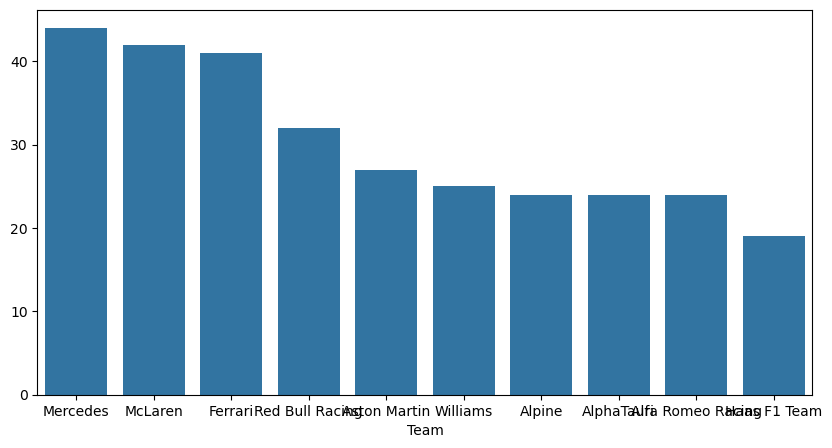

In [14]:
obj_ven = Qualifieranalysis(session)
print('barplot:')
print(obj_ven.bar_graph())

In [27]:
import pandas as pd

# Convert strings to timedelta
get_data_f1["LapTime"] = pd.to_timedelta(get_data_f1["LapTime"])

# Then convert timedelta to total seconds
get_data_f1["LapTime"] = get_data_f1["LapTime"].dt.total_seconds()

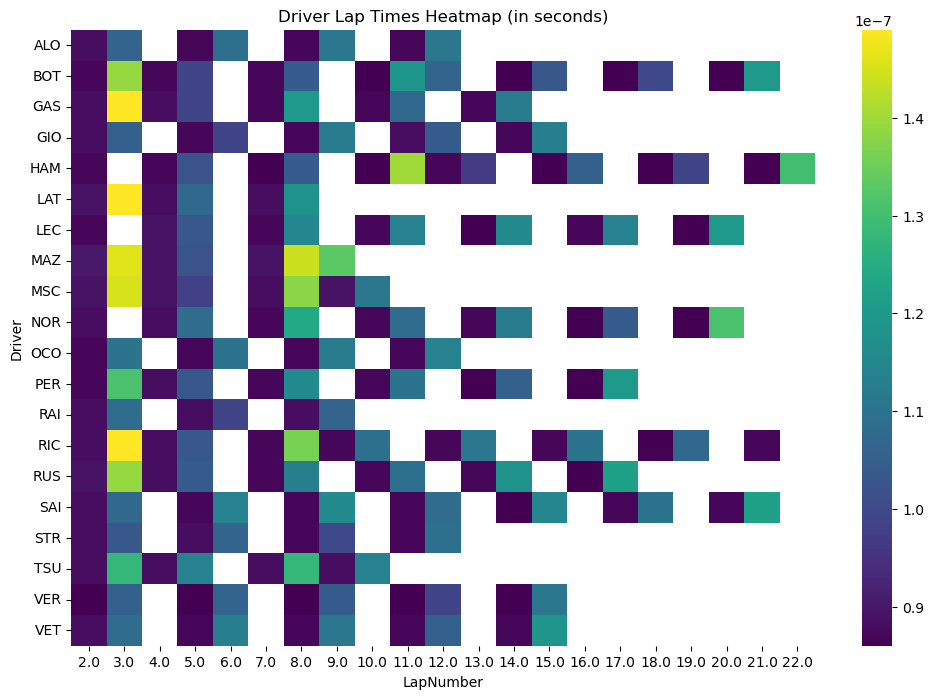

In [28]:
lap_pivot = get_data_f1.pivot_table(
    values="LapTime", index="Driver", columns="LapNumber"
)

plt.figure(figsize=(12,8))
sns.heatmap(lap_pivot, cmap="viridis")
plt.title("Driver Lap Times Heatmap (in seconds)")
plt.show()